# Deteção de Malware com Machine Learning

## Objetivo

Desenvolver um classificador de Machine Learning capaz de distinguir **ficheiros benignos (0)** de **ficheiros maliciosos (1)** a partir de características estruturais e estatísticas de executáveis.

Este notebook documenta o processo completo: **exploração dos dados → preparação → treino → validação → avaliação → interpretação → modelo final**.


## 1. Importação das bibliotecas

Nesta fase importamos as bibliotecas usadas para manipulação dos dados, visualização, treino e avaliação dos modelos.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)


## 2. Carregamento do dataset

O ficheiro CSV está guardado na pasta `data/`. Cada linha representa uma amostra e as colunas representam características do executável ou a informação necessária para a classificação.


In [3]:
df = pd.read_csv("../data/Malware_and_benign_recognition.csv")

display(df.head())
print("Dimensões:", df.shape)


,File,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,...,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize,Malicious
0,e_56_clip.exe,28672,24576,0,4864,4096,0,5368709120,7,49504,...,0.015920,24576,4096,0,7,85,0,0,0,0
1,8d9b19c7af036a2a3f6d710fdfb1f45ca1b476f2ad9484...,234496,72704,0,117581,4096,241664,268435456,4,320,...,3.054267,234496,7648,0,3,103,1,1,0,1
2,e0e908a62601140123531aca205c1d54e6a7ec851f09d4...,1024,1536,0,9134,8192,16384,268435456,3,34112,...,0.081539,1024,0,0,1,1,0,0,0,1
3,42438a67636a6981b4e3209449040f6b393f10fe0636df...,48640,75264,0,18028,4096,53248,4194304,5,32832,...,5.441382,48640,9440,0,3,13,0,0,0,1
4,d_233_CastLaunch.dll,73728,49152,0,9040,4096,0,6442450944,8,16736,...,0.015920,69632,4096,0,31,125,1,2,0,0


Dimensões: (1156, 27)


## 3. Análise exploratória dos dados

Antes de treinar qualquer modelo, verificamos:

- dimensão do dataset;
- nomes das colunas;
- tipos de dados;
- valores em falta;
- duplicados;
- distribuição das classes;
- estatísticas das variáveis numéricas.

O objetivo é perceber se os dados estão em condições para a etapa de Machine Learning.


In [4]:
print("Número de linhas e colunas:", df.shape)

print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
df.info()


Número de linhas e colunas: (1156, 27)

Colunas:
['File', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'NumberOfSections', 'DllCharacteristics', 'SizeOfImage', 'SizeOfHeaders', 'Characteristics', 'Subsystem', 'SectionCount', 'AvgSectionEntropy', 'MaxSectionEntropy', 'MinSectionEntropy', 'TextSectionSize', 'DataSectionSize', 'SuspiciousSectionNames', 'ImportedDLLs', 'ImportedFunctions', 'HasExportTable', 'ExportedFunctions', 'OverlaySize', 'Malicious']

Tipos de dados:
<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   File                     1156 non-null   str    
 1   SizeOfCode               1156 non-null   int64  
 2   SizeOfInitializedData    1156 non-null   int64  
 3   SizeOfUninitializedData  1156 non-null   int64  
 4   AddressOfEntryPoi

In [5]:
print("Valores em falta por coluna:")
display(df.isnull().sum().to_frame("Missing values"))

print("Total de valores em falta:", df.isnull().sum().sum())

print("Número de linhas duplicadas:", df.duplicated().sum())


Valores em falta por coluna:


,Missing values
File,0
SizeOfCode,0
SizeOfInitializedData,0
SizeOfUninitializedData,0
AddressOfEntryPoint,0
BaseOfCode,0
BaseOfData,0
ImageBase,0
NumberOfSections,0
DllCharacteristics,0


Total de valores em falta: 0
Número de linhas duplicadas: 0


Distribuição da variável alvo:
Malicious
0    583
1    573
Name: count, dtype: int64


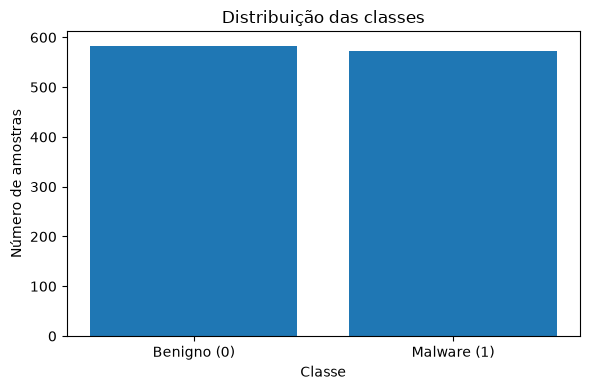

In [6]:
print("Distribuição da variável alvo:")
class_counts = df["Malicious"].value_counts().sort_index()
print(class_counts)

labels = ["Benigno (0)", "Malware (1)"]
plt.figure(figsize=(6, 4))
plt.bar(labels, [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Número de amostras")
plt.tight_layout()
plt.show()


In [8]:
print("Estatísticas das variáveis numéricas:")
display(df.describe().T)


Estatísticas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
SizeOfCode,1156.0,5.881352e+05,1.971440e+06,0.000000,2.048000e+04,8.601600e+04,3.461120e+05,3.564544e+07
SizeOfInitializedData,1156.0,1.641301e+06,7.792484e+06,512.000000,3.686400e+04,9.830400e+04,4.970240e+05,2.161132e+08
SizeOfUninitializedData,1156.0,5.182893e+04,6.584114e+05,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.363558e+07
AddressOfEntryPoint,1156.0,1.018003e+06,6.418082e+06,0.000000,4.944000e+03,1.007200e+04,1.004785e+05,1.184213e+08
BaseOfCode,1156.0,5.199369e+04,6.562292e+05,4096.000000,4.096000e+03,4.096000e+03,4.096000e+03,1.363968e+07
BaseOfData,1156.0,3.988108e+05,1.595476e+06,0.000000,0.000000e+00,0.000000e+00,3.276800e+04,1.434419e+07
ImageBase,1156.0,6.383003e+16,1.083692e+18,65536.000000,2.684355e+08,5.368709e+09,6.442451e+09,1.844674e+19
NumberOfSections,1156.0,6.685121e+00,2.399384e+00,2.000000,5.000000e+00,7.000000e+00,8.000000e+00,2.100000e+01
DllCharacteristics,1156.0,2.229628e+04,1.937298e+04,0.000000,3.200000e+02,1.673600e+04,3.414400e+04,4.963200e+04
SizeOfImage,1156.0,3.394535e+06,1.232523e+07,12288.000000,1.146880e+05,3.706880e+05,3.386368e+06,2.164695e+08


### Observação da análise

Neste dataset existem **1156 amostras e 27 colunas**. `File` é um identificador, enquanto `Malicious` é a variável-alvo. As restantes colunas são features.

A variável alvo tem **583 amostras benignas e 573 amostras de malware**, portanto as classes estão relativamente equilibradas. Não foram encontrados valores em falta nem linhas duplicadas.


## 4. Separação das features e do target

A coluna `File` é apenas um identificador e não deve ser usada como informação preditiva.

A coluna `Malicious` é o target:

- `0` → Benigno
- `1` → Malware

Assim, `X` contém as características usadas para fazer a previsão e `y` contém a resposta que o modelo deve aprender a prever.


In [9]:
TARGET = "Malicious"

X = df.drop(columns=["File", TARGET])
y = df[TARGET]

print("Número de features:", X.shape[1])
print("Número de amostras:", X.shape[0])
print("Features:")
print(X.columns.tolist())


Número de features: 25
Número de amostras: 1156
Features:
['SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'NumberOfSections', 'DllCharacteristics', 'SizeOfImage', 'SizeOfHeaders', 'Characteristics', 'Subsystem', 'SectionCount', 'AvgSectionEntropy', 'MaxSectionEntropy', 'MinSectionEntropy', 'TextSectionSize', 'DataSectionSize', 'SuspiciousSectionNames', 'ImportedDLLs', 'ImportedFunctions', 'HasExportTable', 'ExportedFunctions', 'OverlaySize']


## 5. Divisão entre treino e teste

Reservamos **20% dos dados para teste**. O modelo só aprende com os 80% de treino.

`stratify=y` mantém aproximadamente a mesma proporção de benignos e malware nos dois conjuntos. `random_state=42` torna a divisão reproduzível.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("\nDistribuição no treino:")
print(y_train.value_counts().sort_index())
print("\nDistribuição no teste:")
print(y_test.value_counts().sort_index())


Treino: (924, 25)
Teste: (232, 25)

Distribuição no treino:
Malicious
0    466
1    458
Name: count, dtype: int64

Distribuição no teste:
Malicious
0    117
1    115
Name: count, dtype: int64


## 6. Criação dos modelos

São comparados quatro classificadores:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. Extra Trees

A Logistic Regression utiliza `StandardScaler` dentro de um `Pipeline`, para que a normalização seja aprendida apenas a partir dos dados de treino em cada avaliação.


In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"
    )
}

print("Modelos:", list(models.keys()))


Modelos: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Extra Trees']


## 7. Validação cruzada

Antes de olhar para o teste final, fazemos uma **validação cruzada estratificada de 5 folds** no conjunto de treino.

Esta técnica divide o treino em várias partes, treinando e validando em rotações. Assim obtemos uma estimativa mais robusta do desempenho durante o desenvolvimento.


In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values("F1", ascending=False)
display(cv_df)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Extra Trees,0.993502,0.987097,1.000000,0.993490,0.996804
2,Gradient Boosting,0.993502,0.989201,0.997802,0.993466,0.999039
1,Random Forest,0.992421,0.984992,1.000000,0.992421,0.998543
0,Logistic Regression,0.978361,0.970002,0.986885,0.978353,0.988982


## 8. Treino e avaliação no conjunto de teste

Depois da validação cruzada, cada modelo é treinado com todo o conjunto de treino e avaliado no conjunto de teste, que permaneceu separado.

Usamos várias métricas porque uma única métrica não descreve todos os tipos de erro.


In [14]:
test_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    fitted_models[name] = model

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

test_df = pd.DataFrame(test_results)
display(test_df)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.974138,0.957983,0.991304,0.974359,0.972389
1,Random Forest,0.974138,0.957983,0.991304,0.974359,0.998142
2,Gradient Boosting,0.974138,0.957983,0.991304,0.974359,0.996135
3,Extra Trees,0.974138,0.957983,0.991304,0.974359,0.995652


### Como interpretar as métricas

- **Accuracy:** proporção total de classificações corretas.
- **Precision:** entre as previsões de malware, quantas eram realmente malware.
- **Recall:** entre os malwares existentes, quantos foram detetados.
- **F1:** equilíbrio entre Precision e Recall.
- **ROC-AUC:** capacidade de separar as duas classes usando as probabilidades previstas.

Em cibersegurança, o **Recall da classe Malware** merece atenção, porque um falso negativo corresponde a uma amostra maliciosa classificada como benigna.


## 9. Matriz de confusão do modelo final

Para interpretar os erros de forma concreta, observamos a matriz de confusão do modelo Extra Trees, que é o modelo guardado para reutilização no projeto.

A matriz permite distinguir acertos e erros entre Benigno e Malware.


              precision    recall  f1-score   support

     Benigno       0.99      0.96      0.97       117
     Malware       0.96      0.99      0.97       115

    accuracy                           0.97       232
   macro avg       0.97      0.97      0.97       232
weighted avg       0.97      0.97      0.97       232



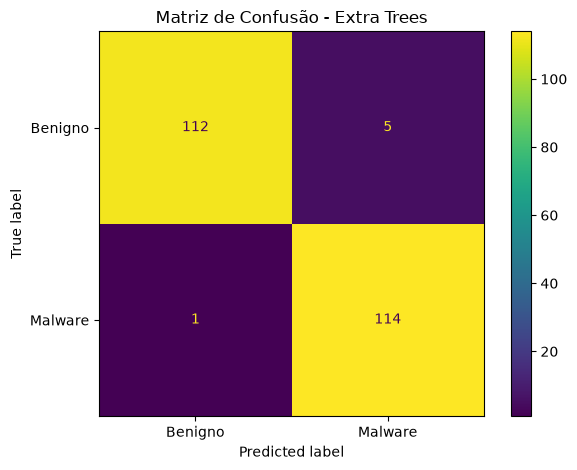

In [15]:
final_model = fitted_models["Extra Trees"]
final_pred = final_model.predict(X_test)

print(classification_report(
    y_test,
    final_pred,
    target_names=["Benigno", "Malware"]
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=["Benigno", "Malware"]
)
plt.title("Matriz de Confusão - Extra Trees")
plt.tight_layout()
plt.show()


## 10. Importância das features

O Extra Trees permite obter uma estimativa da importância de cada feature.

Isto ajuda a perceber quais características tiveram maior contributo para as decisões das árvores. A importância não significa, por si só, causalidade.


,Feature,Importance
10,SizeOfHeaders,0.229820
8,DllCharacteristics,0.170160
20,ImportedDLLs,0.087506
13,SectionCount,0.055617
12,Subsystem,0.052189
6,ImageBase,0.050976
1,SizeOfInitializedData,0.050406
7,NumberOfSections,0.050248
14,AvgSectionEntropy,0.039460
11,Characteristics,0.032630


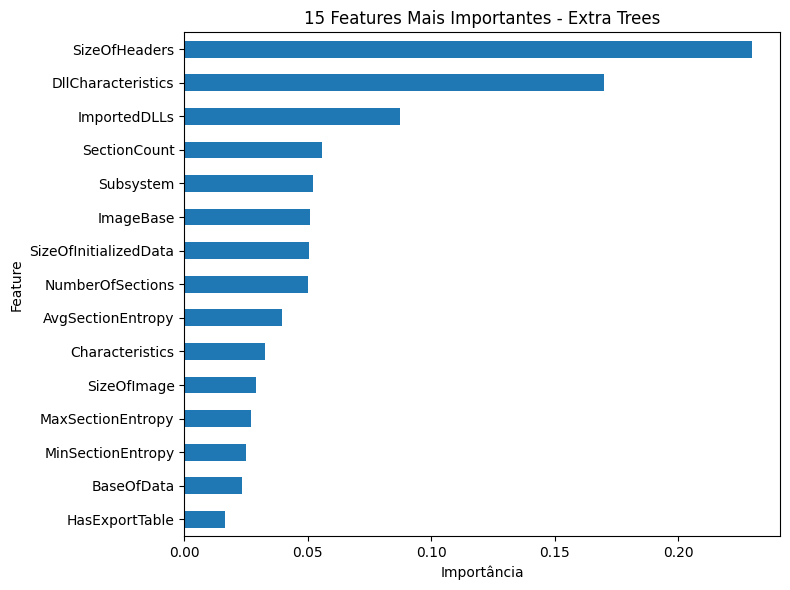

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance.head(15))

plt.figure(figsize=(8, 6))
importance.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    ax=plt.gca()
)
plt.title("15 Features Mais Importantes - Extra Trees")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()


## 11. Guardar resultados

Guardamos as tabelas de comparação e as importâncias para que os resultados também possam ser consultados fora do Notebook.


In [ ]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

cv_df.to_csv(results_dir / "model_comparison_cv.csv", index=False)
test_df.to_csv(results_dir / "model_comparison_test.csv", index=False)
importance.to_csv(results_dir / "feature_importance.csv", index=False)

final_metrics = test_df[test_df["Model"] == "Extra Trees"].drop(columns=["Model"])
final_metrics.to_csv(results_dir / "model_metrics.csv", index=False)

print("Resultados guardados em:", results_dir.resolve())


Resultados guardados em: /mnt/data/work_malware/malware-detection-ml/results


## 12. Modelo final

O modelo Extra Trees é guardado no diretório `models/` para poder ser reutilizado pelo script `predict.py`.

O ficheiro `.joblib` contém o modelo treinado. Para uma utilização real, seria necessário validar o modelo com amostras externas e controlar questões como data leakage e alterações na distribuição dos dados.


In [ ]:
import joblib

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "modelo_extra_trees.joblib"
joblib.dump(final_model, model_path)

print("Modelo guardado em:", model_path.resolve())


Modelo guardado em: /mnt/data/work_malware/malware-detection-ml/models/modelo_extra_trees.joblib


## 13. Conclusão

O projeto aplica aprendizagem supervisionada à classificação binária de executáveis.

O processo realizado foi:

1. carregar e explorar o dataset;
2. verificar qualidade e distribuição dos dados;
3. separar features e target;
4. dividir treino e teste;
5. comparar quatro algoritmos;
6. utilizar validação cruzada;
7. avaliar num conjunto de teste separado;
8. analisar a matriz de confusão;
9. observar a importância das features;
10. guardar o modelo final para reutilização.

Os resultados são experimentais e referem-se a este dataset. Não devem ser interpretados como garantia de deteção de malware desconhecido em ambiente real.
